<a href="https://colab.research.google.com/github/rociocelestial/Challenge2-Data-Science/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [235]:
import requests
import pandas as pd

In [236]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()

df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [237]:

df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

**Verificación**

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

2.- Verificación de Valores Unicos

In [239]:
for col in df.columns:
  print(f"Valores unicos en la columna'{col}:{df[col].nunique()}'")

  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' *50)


Valores unicos en la columna'customerID:7267'
Valores unicos en la columna'Churn:3'
['No' 'Yes' '']
--------------------------------------------------
Valores unicos en la columna'customer.gender:2'
['Female' 'Male']
--------------------------------------------------
Valores unicos en la columna'customer.SeniorCitizen:2'
[0 1]
--------------------------------------------------
Valores unicos en la columna'customer.Partner:2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna'customer.Dependents:2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna'customer.tenure:73'
Valores unicos en la columna'phone.PhoneService:2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna'phone.MultipleLines:3'
['No' 'Yes' 'No phone service']
--------------------------------------------------
Valores unicos en la columna'internet.InternetService:3'
['DSL' 'Fiber optic' 'No']
--------

3.- Valores Duplicados

In [240]:
print('Números de duplicados', df.duplicated().sum())

Números de duplicados 0


4.- Valores Nulos

In [241]:
print('Núumeros nulos', df.isnull().sum())

Núumeros nulos customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


5.- Valores Vacios o en Blanco

In [242]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


**Transformación**

1.- Cambiando la columna 'account.Charges.Total' para float

In [243]:
# from numpy import float64
# no es posible porque numpy solo convierte números no string (object)
# df['account.Charges.Total'].dtype(float64)
# vamos a cambiar valores vacios a valores nulos
df['account.Charges.Total'] = df['account.Charges.Total'].apply(pd.to_numeric, errors='coerce')
print(df['account.Charges.Total'].dtype)


float64


2.- Eliminación de valores vacios en la columna 'Churn'

In [244]:
df = df[df['Churn'].str.strip() != '']
print('Número de filas despues de eliminar los vacios en "Churn":', len(df))

Número de filas despues de eliminar los vacios en "Churn": 7043


In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [246]:
df = df.dropna(subset= ['account.Charges.Total'])


In [247]:
print('Números nulos', df.isnull().sum())

Números nulos customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


3.- Creando un nueva columna, llamada 'Cuentas diarias'

In [248]:
df['cuentas_diarias'] = df['account.Charges.Monthly']/30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


4.- Cambiando el nombre a las columnas

In [249]:
columnas = {                                                        # Diccionario con los nuevos nombres de las columnas.
    'customerID': 'cliente_id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'adulto_mayor',
    'customer.Partner': 'tienen_pareja',
    'customer.Dependents': 'tienen_dependientes',
    'customer.tenure': 'tiempo_contrato',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'cargo_mensual',
    'account.Charges.Total': 'cargo_total'
}

df = df.rename(columns = columnas)
df

,cliente_id,Churn,genero,adulto_mayor,tienen_pareja,tienen_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [250]:
columnas_a_traducir = ['Churn', 'genero', 'tienen_pareja','tienen_dependientes','servicio_telefono','multiples_lineas',
                       'seguridad_online','backup_online','proteccion_dispositivo','soporte_tecnico','streaming_tv','streaming_peliculas',
                       'tipo_contrato','factura_digital']

mapeo = {'Yes':'Si', 'No':'No','Female':'Femenino','Male':'Masculino', 'No phone service': 'Sin servicio de telefono',
         'No internet service':'Sin servicio de internet','One year': 'Anual', 'Month-to-month': 'Mensual', 'Two year': 'Bienal'}

for col in columnas_a_traducir:
  df[col] = df[col].replace(mapeo)



In [251]:
df

,cliente_id,Churn,genero,adulto_mayor,tienen_pareja,tienen_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Si,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,0,No,No,4,Si,No,Fiber optic,...,Si,No,No,No,Mensual,Si,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Si,Masculino,1,Si,No,13,Si,No,Fiber optic,...,Si,No,Si,Si,Mensual,Si,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,1,Si,No,3,Si,No,Fiber optic,...,No,Si,Si,No,Mensual,Si,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Femenino,0,No,No,13,Si,No,DSL,...,No,Si,No,No,Anual,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Si,Masculino,0,Si,No,22,Si,Si,Fiber optic,...,No,No,No,Si,Mensual,Si,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Masculino,0,No,No,2,Si,No,DSL,...,No,No,No,No,Mensual,Si,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Masculino,0,Si,Si,67,Si,No,DSL,...,Si,Si,No,Si,Bienal,No,Mailed check,67.85,4627.65,2.261667


In [252]:
df['adulto_mayor'] = df['adulto_mayor'].replace({1:'Si', 0:'No'})
df.head()

,cliente_id,Churn,genero,adulto_mayor,tienen_pareja,tienen_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,No,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Si,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,No,No,No,4,Si,No,Fiber optic,...,Si,No,No,No,Mensual,Si,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Si,Masculino,Si,Si,No,13,Si,No,Fiber optic,...,Si,No,Si,Si,Mensual,Si,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,Si,Si,No,3,Si,No,Fiber optic,...,No,Si,Si,No,Mensual,Si,Mailed check,83.9,267.40,2.796667


In [253]:
df['metodo_pago'] = df['metodo_pago'].replace({'Mailed check':'Cheque enviado por correo', 'Electronic check':'Cheque electrónico',
                                               'Credit card (automatic)':'Tarjeta de crédito (automático)',
                                               'Bank transfer (automatic)':'Transferencia bancaria (automática)'})
df.head()

,cliente_id,Churn,genero,adulto_mayor,tienen_pareja,tienen_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,No,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.9,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,No,No,No,4,Si,No,Fiber optic,...,Si,No,No,No,Mensual,Si,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Si,Masculino,Si,Si,No,13,Si,No,Fiber optic,...,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,Si,Si,No,3,Si,No,Fiber optic,...,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.9,267.40,2.796667


In [254]:
df

,cliente_id,Churn,genero,adulto_mayor,tienen_pareja,tienen_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,No,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,No,No,No,4,Si,No,Fiber optic,...,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90,280.85,2.463333
3,0011-IGKFF,Si,Masculino,Si,Si,No,13,Si,No,Fiber optic,...,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,Si,Si,No,3,Si,No,Fiber optic,...,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Femenino,No,No,No,13,Si,No,DSL,...,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15,742.90,1.838333
7263,9992-RRAMN,Si,Masculino,No,Si,No,22,Si,Si,Fiber optic,...,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Masculino,No,No,No,2,Si,No,DSL,...,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30,92.75,1.676667
7265,9993-LHIEB,No,Masculino,No,Si,Si,67,Si,No,DSL,...,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85,4627.65,2.261667


#📊 Carga y análisis

1.- Análisis descriptiva

In [255]:
df.describe()

,tiempo_contrato,cargo_mensual,cargo_total,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159940
std,24.545260,30.085974,2266.771362,1.002866
min,1.000000,18.250000,18.800000,0.608333
25%,9.000000,35.587500,401.450000,1.186250
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.862500,3794.737500,2.995417
max,72.000000,118.750000,8684.800000,3.958333


2.- Distribución de la Evasión

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

In [257]:
df['Churn'].unique()

array(['No', 'Si'], dtype=object)

In [258]:
conteo_si_churn = df['Churn'].value_counts().get('Si', 0)
print(f"Número de 'Si' en la columna 'Churn': {conteo_si_churn}")

Número de 'Si' en la columna 'Churn': 1869


In [259]:
conteo_no_churn = df['Churn'].value_counts().get('No', 0)
print(f"Número de 'No' en la columna 'Churn': {conteo_no_churn}")

Número de 'No' en la columna 'Churn': 5163


In [260]:
churn_counts = df['Churn'].value_counts()
churn_counts

,count
Churn,
No,5163
Si,1869


In [261]:
churn_porcentaje = (df['Churn'].value_counts(normalize=True)*100).round(2)
churn_porcentaje

,proportion
Churn,
No,73.42
Si,26.58


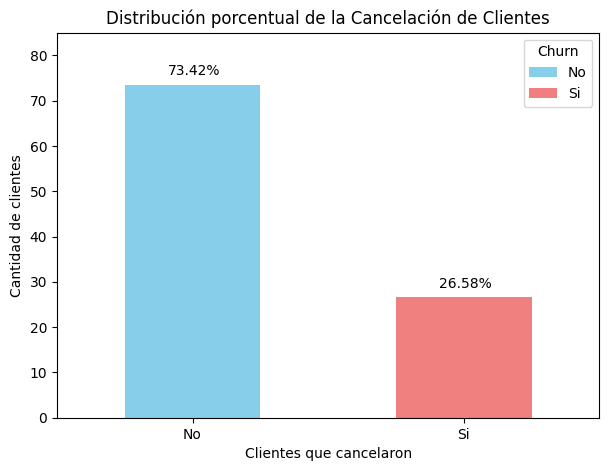

In [262]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch


plt.figure(figsize=(7,5))
ax = churn_porcentaje.plot(kind='bar', color=['skyblue', 'lightcoral'])


plt.title('Distribución porcentual de la Cancelación de Clientes')
plt.xlabel('Clientes que cancelaron')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.ylim(0,85)




for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(1, 10), textcoords='offset points', fontsize=10)


ax.grid(False)



legend_elements = [
    Patch(facecolor='skyblue', label='No'),
    Patch(facecolor='lightcoral', label='Si')
]


ax.legend(handles=legend_elements, title="Churn")


plt.show()

###Podemos observar que el porcentaje de clientes que dejaron la empresa Telecomx es un porcentaje alto, donde surge una necesidad  de analizar esta situación.

2.1 Distribución de la Evasión por Variables Categóricas: **Género**


In [263]:
import plotly.express as px

In [264]:
genero_counts =df['genero'].value_counts()
genero_counts

,count
genero,
Masculino,3549
Femenino,3483


In [265]:
px.histogram(df, x='genero', text_auto=True, color='Churn', barmode='group').update_layout(
    xaxis_showgrid=False,
    yaxis_showgrid=False
).show()

In [266]:
churn_genero = df.groupby('genero')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(2)
print(churn_genero)

Churn         No     Si
genero                 
Femenino   73.04  26.96
Masculino  73.80  26.20


<Figure size 1000x700 with 0 Axes>

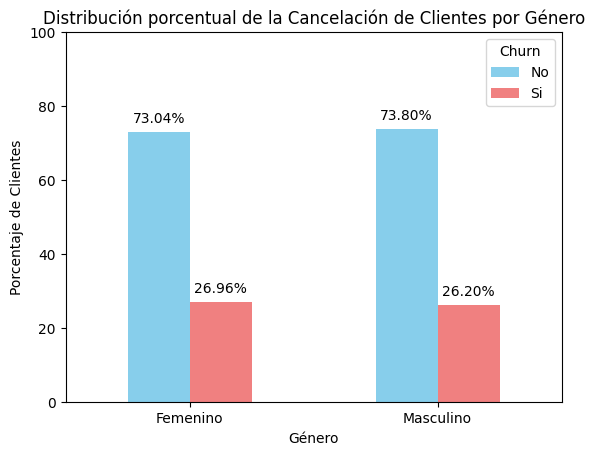

In [267]:
plt.figure(figsize=(10, 7))
ax = churn_genero.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribución porcentual de la Cancelación de Clientes por Género')
plt.xlabel('Género')
plt.ylabel('Porcentaje de Clientes')
plt.xticks(rotation=0)
plt.ylim(0, 100)


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black',
                xytext=(0,5), textcoords='offset points')


ax.grid(False)



legend_elements = [
    Patch(facecolor='skyblue', label='No'),
    Patch(facecolor='red', label='Si')
]


ax.legend(handles=legend_elements, title="Churn")

plt.show()

###Esta información no es tan relevante para nuestro análisis

2.2 Distribución de la Evasión por Variables Categóricas: **Tipo de Contrato**


In [268]:
tipo_contrato_counts =df['tipo_contrato'].value_counts()
tipo_contrato_counts

,count
tipo_contrato,
Mensual,3875
Bienal,1685
Anual,1472


In [269]:
px.histogram(df, x= 'tipo_contrato', text_auto=True, color='Churn', barmode='group').update_layout(
    xaxis_showgrid=False,
    yaxis_showgrid=False
).show()

In [270]:
churn_tipo_contrato = df.groupby('tipo_contrato')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(2)
print(churn_tipo_contrato)

Churn             No     Si
tipo_contrato              
Anual          88.72  11.28
Bienal         97.15   2.85
Mensual        57.29  42.71


In [271]:
import plotly.graph_objects as go


fig = go.Figure()

for col in churn_tipo_contrato.columns:
    fig.add_trace(go.Bar(
        x=churn_tipo_contrato.index,
        y=churn_tipo_contrato[col],
        name=f'Churn: {col}'
    ))

fig.update_layout(
    barmode='stack',
    title='Distribución Porcentual de la Evasión de Clientes por Tipo de Contrato',
    xaxis_title='Tipo de Contrato',
    yaxis_title='Porcentaje de Clientes',
    yaxis=dict(range=[0, 100])
)


for i, contract_type in enumerate(churn_tipo_contrato.index):
    total_height = 0
    for col in churn_tipo_contrato.columns:
        value = churn_tipo_contrato.loc[contract_type, col]
        fig.add_annotation(
            x=contract_type,
            y=total_height + value / 2,
            text=f'{value:.2f}%',
            showarrow=False,
            font=dict(color='black', size=14)
        )
        total_height += value



fig.show()

In [272]:
px.violin(df, x='tipo_contrato', y='tiempo_contrato', color='Churn')

###De estos gráficos por Tipo de Contrato: Mensual, Anual y Bienal, nos permite observar que:

 * **El Contrato Mensual**: Contaban con 3,875, y se muetra que se presenta un abandono de 1,655 clientes, que representan el 42.71%.

 * **El Contrato Anual**: tenian 1,306 clientes y se muetra que se presenta un abandono de 166 clientes, que representa el 11.28%

 * **El Contrato Bienal**: Contaban con  1,685 clientes y se muetra que se presenta un abandono de 48 clientes, que representa 2.85%

#### ***De los graficos se puede concluir que los clientes que tuvieron contrato Mensual, fueron los que más rescindieron contratos con la empresa Telecomx.***




2.3 Distribución de la Evasión por Variables Categóricas:  **Tipo de Internet**

In [273]:
px.histogram(df, x ='tipo_internet', text_auto =True, color = 'Churn', barmode='group' )

In [274]:
churn_tipo_internet = df.groupby('tipo_internet')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(2)
print(churn_tipo_internet)

Churn             No     Si
tipo_internet              
DSL            81.00  19.00
Fiber optic    58.11  41.89
No             92.57   7.43


In [275]:

fig = px.bar(churn_tipo_internet,
             barmode='group',
             title='Distribución Porcentual de la Evasión por Tipo de Internet',
             labels={'value': 'Porcentaje de Clientes', 'tipo_internet': 'Tipo de Servicio de Internet'})

fig.update_layout(
    yaxis_title='Porcentaje de Clientes',
    xaxis_title='Tipo de Servicio de Internet',
    yaxis=dict(range=[0, 100]), # Asegurar que el eje Y vaya de 0 a 100%
    legend_title='Churn',
    xaxis_showgrid=False,
    yaxis_showgrid=False
)



# Añadir etiquetas de texto a las barras para mostrar el porcentaje
fig.update_traces(texttemplate='%{y:.2f}%', textposition='outside')

fig.show()

####En este gráfico podemos observar que los clientes que tenian el sercisio de  internet:
   * **Fiber Optic**: Cuenta con 3,096 clientes de los que se presenta un abandono de clientes de 1,297  que representa el 41.89%.
   * **DSL**: Cuenta con 2,416 clientes de los que se presenta un abandono de clientes de 459 que representa el 19%.
   * **No** : Cuenta con  1,520 clientes de los que se presenta **un** abandono de clientes de 113 que representa el 7.43%.
   
   
####Concluimos que los Clientes con el Tipo de Servicio de Internet con Fiber Optic, fueron los que más desertaron de la empresa TelecomX

In [276]:
px.box(df, x='tipo_internet', y='tiempo_contrato', color='Churn')

2.4- Distribución de la Evasión por Variables Categóricas:  **Metodo de Pago**

In [277]:
px.histogram(df, x = 'metodo_pago', text_auto = True, color = 'Churn', barmode = 'group')

In [278]:
churn_tipo_internet = df.groupby('metodo_pago')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(2)
print(churn_tipo_internet)

Churn                                   No     Si
metodo_pago                                      
Cheque electrónico                   54.71  45.29
Cheque enviado por correo            80.80  19.20
Tarjeta de crédito (automático)      84.75  15.25
Transferencia bancaria (automática)  83.27  16.73


In [279]:
fig = px.bar(churn_tipo_internet,
             barmode='group',
             title='Distribución Porcentual de la Evasión por Metodo de Pago',
             labels={'value': 'Porcentaje de Clientes', 'metodo_pago': 'Metodo de Pago'})

fig.update_layout(
    yaxis_title='Porcentaje de Clientes',
    xaxis_title='Método de Pago',
    yaxis=dict(range=[0, 100]),
    legend_title='Churn',

    xaxis_showgrid=False,
    yaxis_showgrid=False
)


fig.update_traces(texttemplate='%{y:.2f}%', textposition='outside')

fig.show()

####Este gráfico  muestra que la empresa TelecomX, tiene cuatro metodos de Pagos:

* **Cheque Electronico**: 2,365 clientes de los que se  presenta un abandono de  de 1,071 que representa el 45.29%.

* **Cheque enviado por Correo**:  1,604 clientes de los que se  presenta un abandono de clientes de 308 que representa el 19.20%.

* **Transferencia Bancaria(automático)**:  1,542 clientes de los que se  presenta un abandono de clientes de 258 que representa el 16.73%.

* **Tarjeta de Crédito(automática)**:  1,521 clientes de los que se  presenta un abandono de clientes de 232 que representa el 15.25%.

####Se puede concluir que clientes que cuentan con el Metodo de pago de cheque electronico son los que más han cancelado el servicio con la empresa TelecomX

2.5 Distribución de la Evasión por Variable Categórica: **Adulto Mayor**

In [280]:
conteo_si_adulto_mayor= df['adulto_mayor'].value_counts().get('Si', 0)
print(f"Número de 'Si' en la columna 'adulto_mayor': {conteo_si_adulto_mayor}")

Número de 'Si' en la columna 'adulto_mayor': 1142


In [281]:
conteo_no_adulto_mayor = df['adulto_mayor'].value_counts().get('No', 0)
print(f"Número de 'No' en la columna 'adulto_mayor': {conteo_no_adulto_mayor}")

Número de 'No' en la columna 'adulto_mayor': 5890


In [282]:
px.histogram(df, x ='adulto_mayor', text_auto = True, color = 'Churn', barmode = 'group')

In [283]:
churn_adulto_mayor = df.groupby('adulto_mayor')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(2)
print(churn_adulto_mayor)

Churn            No     Si
adulto_mayor              
No            76.35  23.65
Si            58.32  41.68


In [284]:
fig = px.bar(churn_adulto_mayor,
             barmode='group',
             title='Distribución Porcentual de la Evasión por la categoria  Adulto Mayor',
             labels={'value': 'Porcentaje de Clientes', 'adulto_mayor': 'Adulto Mayor'})

fig.update_layout(
    yaxis_title='Porcentaje de Clientes',
    xaxis_title='Adulto Mayor',
    yaxis=dict(range=[0, 100]),
    legend_title='Churn',
    xaxis_showgrid=False,
    yaxis_showgrid=False
)


fig.update_traces(texttemplate='%{y:.2f}%', textposition='outside')

fig.show()


###Se puede deducir de en este gráfico, que la empresa cuenta con clientes de tipo:

* **Adulto Mayor (<65 años)**:  1,142 , de los que se presenta un abandono de  de 476, que representa el 41.68%

* **No Adulto Mayor**:   5,890 Clientes, de los que se presenta un abandono de  de 1,393 que representa el 23.65%.

####**Conclusión**:  Aunque la empresa goza de una base sólida y mayoritaria de clientes >65 con una tasa de abandono moderada (23.65%), enfrenta una fuga crítica en el segmento de adultos mayores, donde pierde al 41.68% de sus usuarios. Esta brecha evidencia que, si bien el negocio es estable para el público general, su estrategia actual falla gravemente en retener al nicho de mayor edad.





2.6 Distribución de la Evasión por Variable Categórica:  **Tienen  Pareja**

In [285]:
df['tienen_pareja'].value_counts()


,count
tienen_pareja,
No,3639
Si,3393


In [286]:
px.histogram(df, x = 'tienen_pareja', text_auto = True, color = 'Churn', barmode = 'group')

In [287]:
churn_tienen_pareja = df.groupby('tienen_pareja')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(2)
print(churn_tienen_pareja)

Churn             No     Si
tienen_pareja              
No             67.02  32.98
Si             80.28  19.72


In [288]:
fig = px.bar(churn_tienen_pareja,
             barmode='group',
             title='Distribución Porcentual de la Evasión por la categoria  Tienen Pareja',
             labels={'value': 'Porcentaje de Clientes', 'tienen_pareja': 'Tienen Pareja'})

fig.update_layout(
    yaxis_title='Porcentaje de Clientes',
    xaxis_title='tienen Pareja',
    yaxis=dict(range=[0, 100]),
    legend_title='Churn',
    xaxis_showgrid=False,
    yaxis_showgrid=False
)


fig.update_traces(texttemplate='%{y:.2f}%', textposition='outside')

fig.show()

###Podemos observar que la empresa cuenta con Clientes que:

* **Tienen Pareja**: 3,393 Clientes, de los que han abandonado 669, que representa el 19.72%.
* **No Tienen Pareja (solteros)**: 3,639 Clientes, de los que  han abandonado 1,200, que representa el 32.98%

####Se concluye que empresa demuestra una mejor retención en los clientes que tienen pareja, con una tasa de abandono de solo el 19.72%. Por el contrario, el segmento de solteros representa un punto de debilidad, ya que casi uno de cada tres (32.98%) decide abandonar el servicio, lo que indica que la oferta actual es considerablemente menos efectiva para este grupo.

2.7 Distribución de la Evasión por Variable Categórica:  **Tienen Dependientes**

In [289]:
df['tienen_dependientes'].value_counts()

,count
tienen_dependientes,
No,4933
Si,2099


In [290]:
fig =  px.histogram(df, x = 'tienen_dependientes', text_auto = True, color = 'Churn', barmode = 'group')

fig.update_traces(marker_line_width=0)

fig.update_layout(
    xaxis_showgrid=False,
    yaxis_showgrid=False
)
fig.show()

In [291]:
churn_tienen_dependientes = df.groupby('tienen_dependientes')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(2)
print(churn_tienen_dependientes)

Churn                   No     Si
tienen_dependientes              
No                   68.72  31.28
Si                   84.47  15.53


In [292]:
fig = px.bar(churn_tienen_dependientes,
             barmode='group',
             title='Distribución Porcentual de la Evasión por la categoria  Tienen Dependientes',
             labels={'value': 'Porcentaje de Clientes', 'tienen_dependientes': 'Tienen Dependientes'})

fig.update_layout(
    yaxis_title='Porcentaje de Clientes',
    xaxis_title='Tienen Dependientes',
    yaxis=dict(range=[0, 100]), # Asegurar que el eje Y vaya de 0 a 100%
    legend_title='Churn'
)

# Añadir etiquetas de texto a las barras para mostrar el porcentaje
fig.update_traces(texttemplate='%{y:.2f}%', textposition='outside')

fig.show()



###La empresa TelecomX cuenta con Clientes que:

* **Tienen Dependientes**: Tenia  2,099 Clientes, de los cuales han abandonado 326 Clientes, que representa el 15.53%.

* **No Tienen Dependientes**: Tenia  4,933 Clientes, de los cuales han abandonado 1,543 Clientes, que representa el 31.28%.

####Se observa que la empresa logra una retención mucho más efectiva en los clientes que tienen dependientes, registrando una tasa de abandono baja del 15.53%. Por el contrario, los clientes sin dependientes (que representan el grupo mayoritario de casi 5,000 personas) abandonan el servicio al doble de velocidad, con un alarmante 31.28%. Esto indica que los servicios de la empresa son más estables y atractivos para núcleos familiares, pero fallan en fidelizar a los usuarios individuales


3.-Distribución de la Evasión por **Variables Numéricas**

3.1 **Relación Tiempo contrato - Churn**

In [293]:
churn_tiempo_contrato = df.groupby('tiempo_contrato')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0).round(2)
print(churn_tiempo_contrato)

Churn               No     Si
tiempo_contrato              
1                38.01  61.99
2                48.32  51.68
3                53.00  47.00
4                52.84  47.16
5                51.88  48.12
...                ...    ...
68               91.00   9.00
69               91.58   8.42
70               90.76   9.24
71               96.47   3.53
72               98.34   1.66

[72 rows x 2 columns]


In [294]:
fig = px.bar(churn_tiempo_contrato,
             barmode='group',
             title='Distribución Porcentual de la Evasión por la categoria Tiempo Contrato',
             labels={'value': 'Porcentaje de Clientes', 'tiempo_contrato': 'Tiempo Contrato'})

fig.update_layout(
    yaxis_title='Porcentaje de Clientes',
    xaxis_title='Tiempo Contrato',
    yaxis=dict(range=[0, 100]),
    legend_title='Churn'
)


fig.update_traces(texttemplate='%{y:.2f}%', textposition='outside')

fig.show()

\###En el **primer mes** es donde más se producen la cancelación de los servicios de la empresa Telecomx

3.2-**Relación Cargo Mensual - Churn** / **Relación Cargo Total - Churn**

In [295]:
import plotly.express as px


fig_mensual = px.box(df, y='cargo_mensual', color='Churn',
                     title='Distribución de Cargo Mensual por Evasión de Clientes',
                     labels={'cargo_mensual': 'Cargo Mensual', 'Churn': 'Evasión'})
fig_mensual.show()



fig_total = px.box(df, y='cargo_total', color='Churn',
                   title='Distribución de Cargo Total por Evasión de Clientes',
                   labels={'cargo_total': 'Cargo Total', 'Churn': 'Evasión'})
fig_total.show()

In [296]:

fig_scatter = px.scatter(df,
                         x='tiempo_contrato',
                         y='cargo_mensual',
                         color='Churn',
                         title='¿Influye el precio y el tiempo en que un cliente se vaya?',
                         labels={'tiempo_contrato': 'Meses en la empresa', 'cargo_mensual': 'Cargo Mensual'},
                         trendline="ols")
fig_scatter.show()

In [297]:

fig_scatter = px.scatter(df,
                         x='tiempo_contrato',
                         y='cargo_total',
                         color='Churn',
                         title='¿Influye el precio y el tiempo en que un cliente se vaya?',
                         labels={'tiempo_contrato': 'Meses en la empresa', 'cargo_total': 'Cargo Total'},
                         trendline="ols")
fig_scatter.show()

###Se observa que el abandono está impulsado por el alto costo inicial: los clientes nuevos suelen recibir facturas mensuales más elevadas, lo que genera una salida prematura. Esto se confirma al ver que quienes cancelan tienen un cargo total bajo, lo que indica que se van al inicio de su relación con la empresa, antes de consolidarse. En conclusión, el precio elevado actúa como una barrera que expulsa al cliente antes de que este genere lealtad a largo plazo.

###Análisis Opcional


**La relación entre la Cuenta Diaria y la Evasión**.

In [298]:
px.histogram(df, x='cuentas_diarias', text_auto=True, color='Churn', barmode='group').update_layout(
    xaxis_showgrid=False,
    yaxis_showgrid=False
).show()

In [299]:
px.histogram(df, x='cuentas_diarias', color='Churn', barmode='group', histnorm='percent')

In [300]:

px.histogram(df, x='cuentas_diarias', color='Churn', barmode='group',
             histnorm='percent', text_auto='.1f')

###Podemos observar que los Clientes se van cuando tienen contratos más caros


In [301]:
churn_cuenta_diaria = df.groupby('cuentas_diarias')['Churn'].value_counts(normalize=True)
print(churn_cuenta_diaria)

cuentas_diarias  Churn
0.608333         No       1.0
0.613333         No       1.0
0.618333         No       1.0
0.623333         No       1.0
0.625000         No       1.0
                         ... 
3.940000         No       1.0
3.945000         Si       1.0
3.953333         No       1.0
3.955000         No       1.0
3.958333         No       1.0
Name: proportion, Length: 2369, dtype: float64


###Para saber como la Cantidad de Servicios afecta a Churn(la deserción del cliente)

In [302]:
import pandas as pd
import plotly.express as px


servicios = [
    'servicio_telefono', 'multiples_lineas', 'tipo_internet', 'seguridad_online',
    'backup_online', 'proteccion_dispositivo', 'soporte_tecnico',
    'streaming_tv', 'streaming_peliculas'
]


for col in servicios:
    df[col] = df[col].map({'Si': 1, 'No': 0})


df['total_servicios'] = df[servicios].sum(axis=1)

In [303]:
fig = px.histogram(
    df,
    x='total_servicios',
    color='Churn',
    barnorm='percent',
    text_auto='.1f',
    title='<b>Probabilidad de Churn según Volumen de Servicios</b>',
    color_discrete_map={'Si': '#E74C3C', 'No': '#27AE60'},
    category_orders={'total_servicios': sorted(df['total_servicios'].unique())}
)

fig.update_layout(
    xaxis_title="Cantidad de Servicios Contratados (0 a 9)",
    yaxis_title="Porcentaje de Usuarios (%)",
    bargap=0.15,
    plot_bgcolor='white'
)

fig.show()

In [304]:
import plotly.express as px


fig = px.histogram(
    df,
    x='total_servicios',
    color='tipo_contrato',
    barmode='group',
    text_auto=True,
    title='<b>Relación entre Cantidad de Servicios y Tipo de Contrato</b>',
    category_orders={'total_servicios': sorted(df['total_servicios'].unique())}
)

fig.update_layout(
    xaxis_title="Número de Servicios Contratados",
    yaxis_title="Cantidad de Clientes",
    xaxis={'tickmode': 'linear'},
    plot_bgcolor='white'
)

fig.show()

###Los datos indican que la empresa no logra fidelizar a sus usuarios. La combinación de facturas elevadas por múltiples servicios y la falta de compromiso contractual genera que el cliente nuevo no perciba un valor suficiente, optando por abandonar la compañía de forma prematura antes de consolidar su relación con la marca.

In [305]:
import pandas as pd
import plotly.express as px


df['churn_num'] = df['Churn'].map({'Si': 1, 'No': 0})

columnas_analisis = [
    'cuentas_diarias', 'churn_num'
]

df_corr = df[columnas_analisis].corr()

In [306]:
fig = px.imshow(
    df_corr,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title="<b>Matriz de Correlación: Cuentas Diarias vs Churn</b>"
)

fig.update_layout(width=500, height=500)
fig.show()

###Diagnóstico Final de Retención
La correlación de 0.19 confirma que el uso frecuente no garantiza la lealtad. Por el contrario, los usuarios más activos son más propensos a la evasión porque el alto costo del servicio termina pesando más que el beneficio del uso. En resumen, el diagnóstico se divide en tres frentes críticos:

Clientes Nuevos: Al presentar un bajo uso y pocos servicios, se evidencia que no encuentran el valor inicial debido a un proceso de integración (onboarding) deficiente.

Contratos Mes a Mes: Este modelo elimina cualquier barrera de salida, otorgando al cliente facilidad total para abandonar la empresa en cualquier momento.

Power Users: Aunque son usuarios intensivos, su alta actividad los vuelve más sensibles al precio; el gasto elevado supera la satisfacción del servicio, provocando que se marchen a pesar de su alto consumo.

In [307]:
import pandas as pd
import plotly.express as px

df['churn_num'] = df['Churn'].map({'Si': 1, 'No': 0})

columnas_analisis = [
    'total_servicios', 'churn_num'
]

df_corr = df[columnas_analisis].corr()

In [308]:
fig = px.imshow(
    df_corr,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title="<b>Matriz de Correlación: Total Servicios vs Churn</b>"
)

fig.update_layout(width=500, height=500)
fig.show()

In [309]:

columnas_finales = ['cargo_mensual', 'churn_num']


df_corr_final = df[columnas_finales].corr()


fig = px.imshow(
    df_corr_final,
    text_auto=".2f",
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title="<b>Validación Final: El Impacto del Gasto Mensual en el Churn</b>"
)
fig.show()

#####La correlación positiva de 0.19 confirma que el uso intensivo del servicio no se traduce en lealtad, sino en una mayor sensibilidad al precio. Al estar vinculados directamente el nivel de actividad y el cargo mensual, el cliente percibe que un mayor uso solo conlleva un costo más alto, sin recibir beneficios claros por su fidelidad.  Esta falta de incentivos, sumada a un modelo de contratación sin permanencia, transforma a nuestros usuarios más activos en el segmento de mayor vulnerabilidad. En definitiva, la empresa está castigando el uso intensivo en lugar de premiarlo, facilitando que sus mejores clientes busquen alternativas más económicas.

#📄Informe final

##**Introducción:**

TelecomX, empresa líder en el sector de telecomunicaciones, enfrenta actualmente el desafío estratégico de una elevada tasa de cancelación de clientes (churn). Ante esta situación, surge la necesidad crítica de identificar y comprender los factores determinantes que impulsan la pérdida de usuarios para asegurar la sostenibilidad del negocio.

Con el objetivo de abordar esta problemática, se llevará a cabo un proceso integral de recopilación, procesamiento y análisis de datos mediante el uso del lenguaje Python y sus bibliotecas especializadas. Este flujo de trabajo permitirá extraer insights de alto valor sobre el comportamiento y perfil de los consumidores.

Los resultados obtenidos servirán como base fundamental para el desarrollo de modelos predictivos y el diseño de estrategias basadas en datos, orientadas específicamente a mitigar la evasión y fortalecer la fidelización de los clientes.


##**Limpieza y Tratamiento de Datos:**

El presente documento detalla el procedimiento técnico seguido para la obtención, estructuración y saneamiento del conjunto de datos TelecomX.

1. Importación de Bibliotecas y Obtención de Datos
En la primera etapa, se preparó el entorno de Python utilizando herramientas que permiten un flujo de trabajo dinámico y eficiente:

requests: Utilizada para la ingesta de datos directamente desde la web. Este enfoque profesional evita la descarga manual de archivos, garantizando que el notebook trabaje siempre con la versión más reciente alojada en la nube y facilitando la reproducibilidad del proyecto.

pandas (as pd): Empleada para la manipulación, limpieza y análisis tabular de la información.

Procedimiento de carga:
Se realizó una petición GET a la URL del repositorio de origen. El contenido obtenido en formato JSON se convirtió en un diccionario de Python y, posteriormente, se aplicó la función pd.json_normalize(data). Este paso es fundamental para desglosar estructuras anidadas en columnas distintas, permitiendo su tratamiento como un DataFrame de Pandas.

2. Diagnóstico y Tratamiento de Datos
Una vez estructurada la información, se inició la fase de inspección y limpieza para asegurar la calidad del dataset:

Identificación y Manejo de Vacíos: Se detectaron celdas con valores en blanco o espacios vacíos, los cuales fueron convertidos formalmente a valores nulos. Posteriormente, se procedió a la eliminación de estos registros para evitar inconsistencias en el análisis.

Normalización y Estandarización: Se llevó a cabo un proceso de ajuste del dataset que incluyó:

Traducción de variables: Conversión de las categorías a un idioma consistente.

Renombrado de columnas: Ajuste de las etiquetas de las variables para mejorar la legibilidad y garantizar la uniformidad técnica del archivo.






**Distribución de la deserción de los Clientes de la Empresa TelecomX**

1.-**Deserción Total**

Podemos observar que el porcentaje de Clientes que dejaron la Empresa Telecomx es un porcentaje significativo que amerita hacer un análisis exhaustivo.

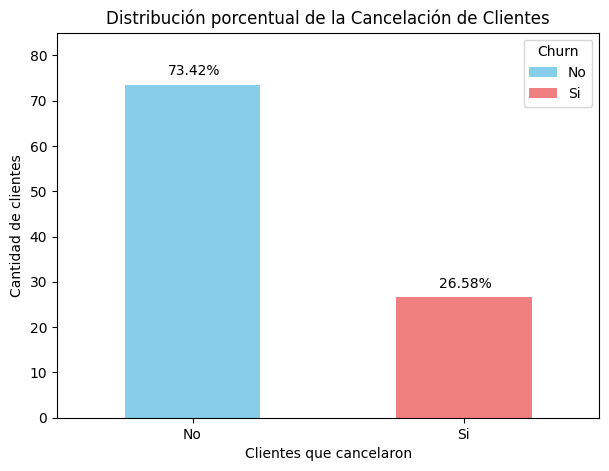




2. **Análisis por Tipo de Contrato**
La estructura comercial de TelecomX se basa en tres modalidades de contratación: Mensual, Anual y Bienal. El comportamiento de la cartera de clientes según estas categorías revela lo siguiente:

Contrato Mensual (Mes a Mes): Representa el segmento más voluminoso con 3,875 clientes. Sin embargo, es también el punto de mayor vulnerabilidad, registrando 1,655 bajas, lo que equivale a una tasa crítica de abandono del 42.71%.

Contrato Anual: De una base de 1,306 clientes, esta modalidad presentó un abandono de 166 usuarios, manteniendo una tasa de deserción del 11.28%.

Contrato Bienal: Es el modelo de mayor estabilidad. Con 1,685 clientes, registró apenas 48 bajas, lo que representa una tasa residual de deserción de solo el 2.85%.

**Conclusión del Hallazgo**
Existe una correlación directa entre la duración del compromiso contractual y la lealtad del cliente. Los usuarios bajo la modalidad de Contrato Mensual son quienes rescinden su relación con TelecomX con mayor frecuencia.

Esto indica que la ausencia de un compromiso a largo plazo incrementa la volatilidad del segmento, haciendo que los usuarios sean significativamente más propensos a abandonar el servicio ante cualquier insatisfacción operativa o frente a ofertas agresivas de la competencia.

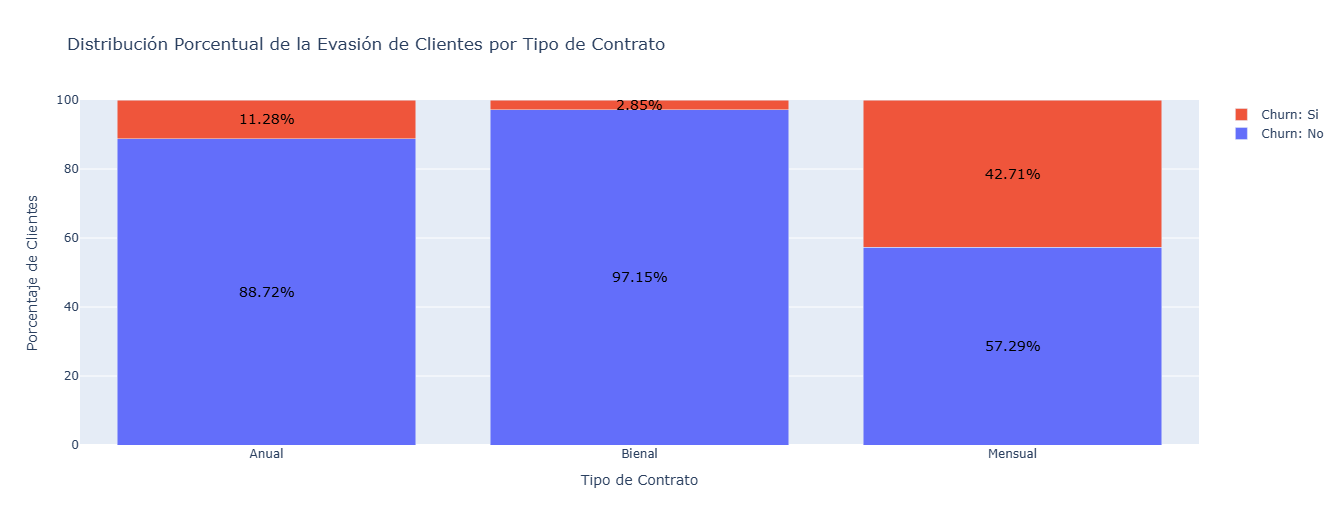

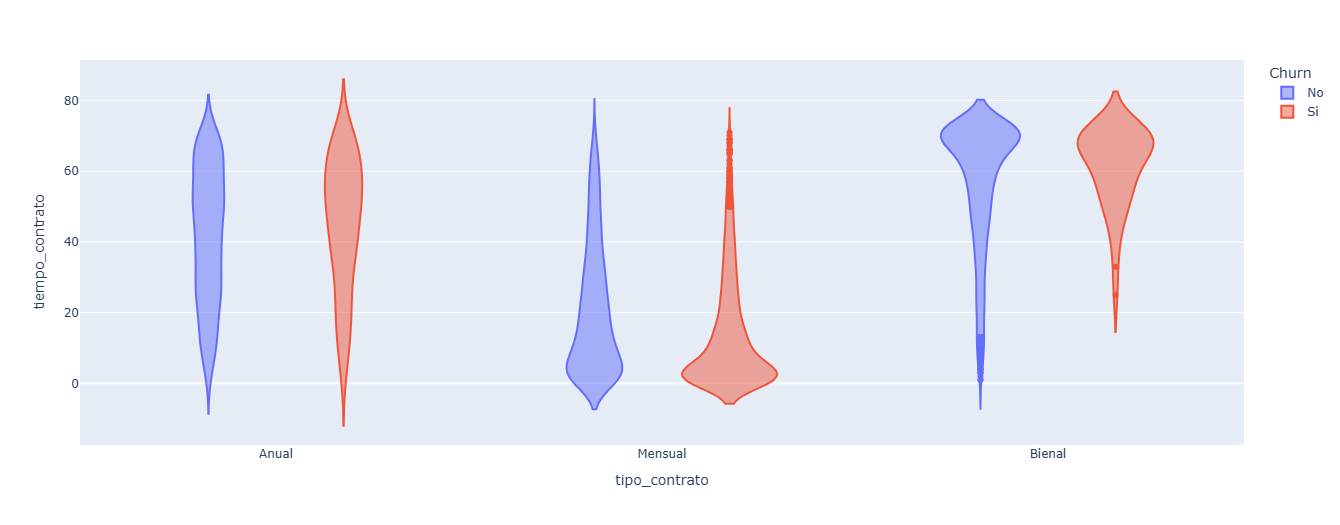





3. **Análisis por Tipo de Servicio de Internet**
La oferta de conectividad de TelecomX se divide en tres categorías principales: Fibra Óptica (Fiber Optic), DSL y un segmento de usuarios Sin Servicio de Internet. El comportamiento de deserción en estas líneas de negocio es el siguiente:

* Fibra Óptica (Fiber Optic): Es el servicio con mayor volumen de usuarios (3,096 clientes), pero también el de mayor criticidad, registrando 1,297 bajas. Esto representa una tasa de abandono del 41.89%.

* DSL: Contaba con una base de 2,416 clientes, de los cuales 459 usuarios rescindieron el servicio, lo que equivale a una tasa de deserción del 19%.

* Sin Servicio de Internet (No): Este segmento, con 1,520 clientes, muestra la mayor estabilidad con solo 113 bajas, representando una tasa de abandono residual del 7.43%.

**Conclusión del Hallazgo**
Los datos revelan que los usuarios del servicio de Fibra Óptica son el perfil con mayor propensión a la deserción en TelecomX. A pesar de ser la tecnología de mayor capacidad, presenta un índice de abandono significativamente superior al de las conexiones DSL o de los clientes sin internet.

Este comportamiento sugiere la necesidad de revisar factores críticos en este producto específico, tales como la estabilidad técnica de la red de fibra, la competitividad de sus precios frente al mercado o la calidad del soporte especializado para este segmento.


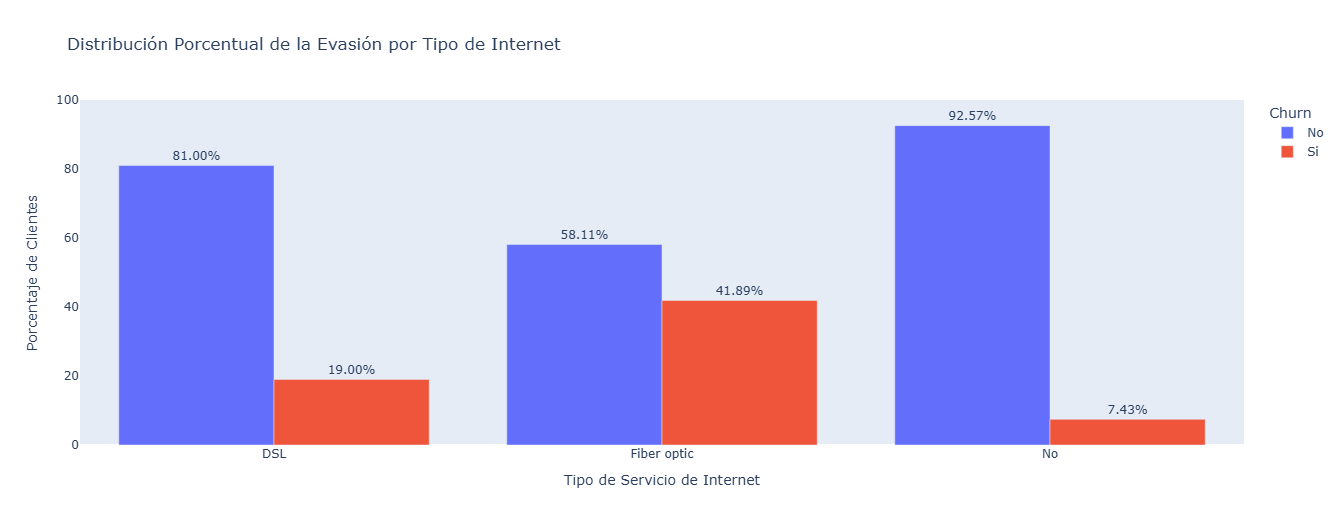




**4. Análisis por Método de Pago**

El ecosistema financiero de TelecomX se compone de cuatro modalidades de pago. El análisis de estas variables revela una disparidad significativa en la lealtad de los clientes según el canal utilizado para sus transacciones:

* Cheque Electrónico (Electronic Check): Es el método con mayor volumen de transacciones (2,365 clientes), pero registra una cifra crítica de 1,071 bajas, lo que representa la tasa de abandono más alta de la compañía con un 45.29%.

* Cheque enviado por Correo (Mailed Check): Contaba con una base de 1,604 clientes, de los cuales 308 usuarios rescindieron el servicio, equivalente a una tasa de deserción del 19.20%.

* Transferencia Bancaria Automática (Bank Transfer): De una cartera de 1,542 clientes, se registraron 258 bajas, manteniendo una tasa de abandono controlada del 16.73%.

* Tarjeta de Crédito Automática (Credit Card): Presenta los niveles más altos de retención. De 1,521 clientes, solo 232 cancelaron el servicio, lo que representa la tasa de deserción más baja con un 15.25%.

**Conclusión del Hallazgo**
Los usuarios que gestionan sus pagos mediante Cheque Electrónico constituyen el segmento de mayor riesgo para TelecomX. Por el contrario, los métodos de pago automáticos (Transferencia y Tarjeta de Crédito) muestran una correlación directa con una mayor estabilidad y permanencia del cliente.

Este comportamiento sugiere que el proceso de pago manual o a través de cheque electrónico podría estar generando fricciones administrativas, errores en la facturación o simplemente atrayendo a un perfil de cliente con menor intención de permanencia, convirtiéndose en un punto crítico que requiere una intervención estratégica inmediata.




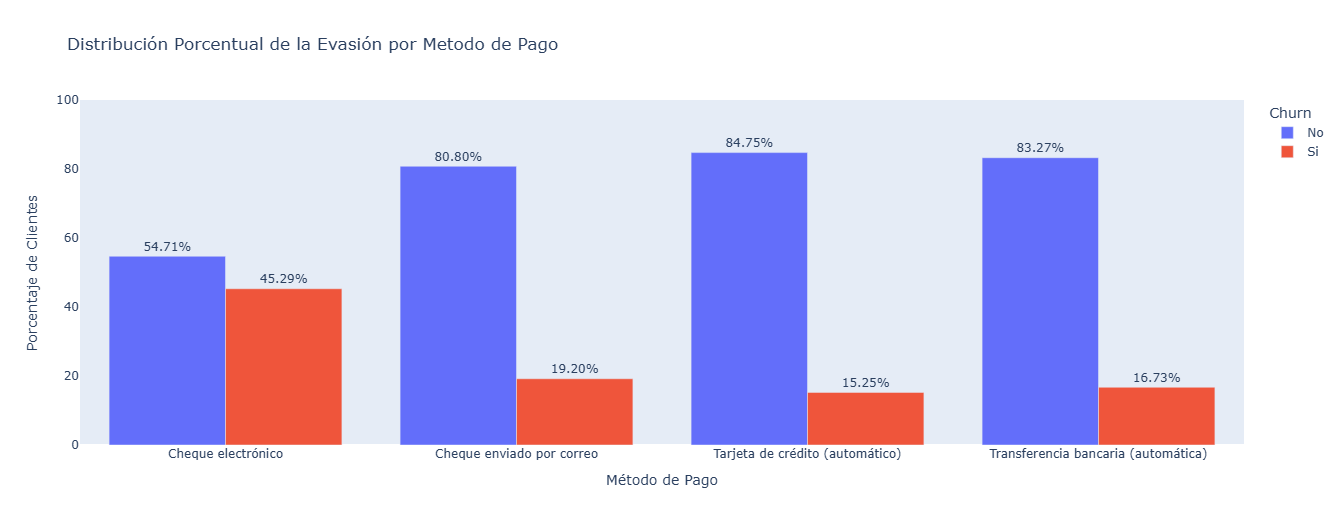





5. **Segmentación por Rango de Edad (Adulto Mayor)**

El análisis demográfico de TelecomX permite identificar comportamientos diferenciados en la fidelidad de marca según el rango de edad de los usuarios. Los datos revelan una dualidad crítica entre la tasa de riesgo y el volumen total de pérdidas:

* Adulto Mayor (Más de 65 años): Este segmento cuenta con una base de 1,142 clientes. Se registraron 476 bajas, lo que representa una tasa de abandono del 41.68%. Es el grupo con mayor vulnerabilidad porcentual.

* No Adulto Mayor: Constituye el núcleo principal de la cartera con 5,890 clientes. De este grupo, 1,393 usuarios rescindieron el servicio, lo que equivale a una tasa de deserción del 23.65%.

**Conclusión del Hallazgo**
El análisis requiere una interpretación desde dos perspectivas fundamentales para la toma de decisiones:

Vulnerabilidad Específica: El grupo de Adultos Mayores presenta la mayor tasa de riesgo. Proporcionalmente, este segmento es casi dos veces más propenso a abandonar el servicio que el resto de los clientes, lo que sugiere una posible falta de canales de atención adecuados o dificultades con la interfaz tecnológica de los servicios.

Impacto en el Volumen: A pesar de la tasa anterior, el impacto real en el volumen de pérdidas de la compañía proviene mayoritariamente del segmento No Adulto Mayor. Debido a que este grupo es considerablemente más grande, sus cancelaciones representan la mayor pérdida de ingresos en términos absolutos.





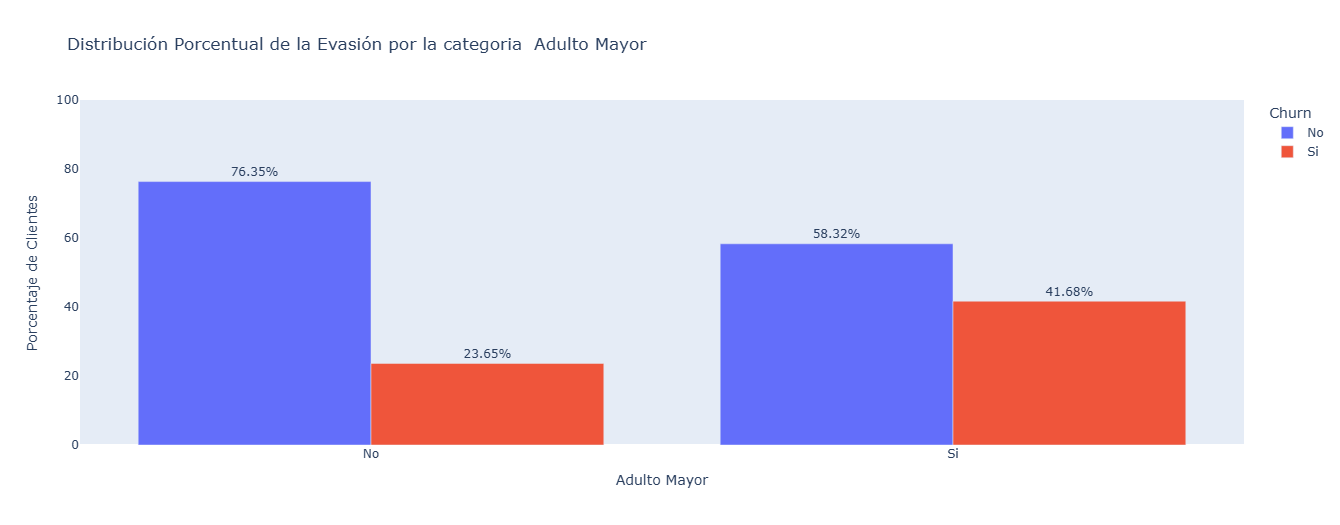



6. **Segmentación por Estado Civil (Pareja)**

El análisis del comportamiento de la cartera de TelecomX según la situación sentimental de los usuarios permite identificar perfiles de lealtad diferenciados. Los datos extraídos del gráfico revelan lo siguiente:

* Sin Pareja (Solteros): Constituye el segmento mayoritario de la base de datos con 3,639 clientes. Sin embargo, presenta el nivel de deserción más alto, con 1,200 bajas, lo que equivale a una tasa de abandono del 32.98%.

* Con Pareja: De una base de 3,393 clientes, este grupo registró 669 cancelaciones, manteniendo una tasa de deserción significativamente menor del 19.72%.

**Conclusión del Hallazgo**
Los clientes sin pareja representan tanto el mayor volumen de la base de datos como la tasa de riesgo más elevada para la compañía.

Este comportamiento sugiere que los usuarios solteros conforman un segmento con menor fidelidad de marca en comparación con aquellos que tienen pareja. La estabilidad en el núcleo familiar parece correlacionarse directamente con una mayor permanencia en los servicios de TelecomX, mientras que los clientes solteros muestran una mayor volatilidad y propensión al cambio de proveedor.


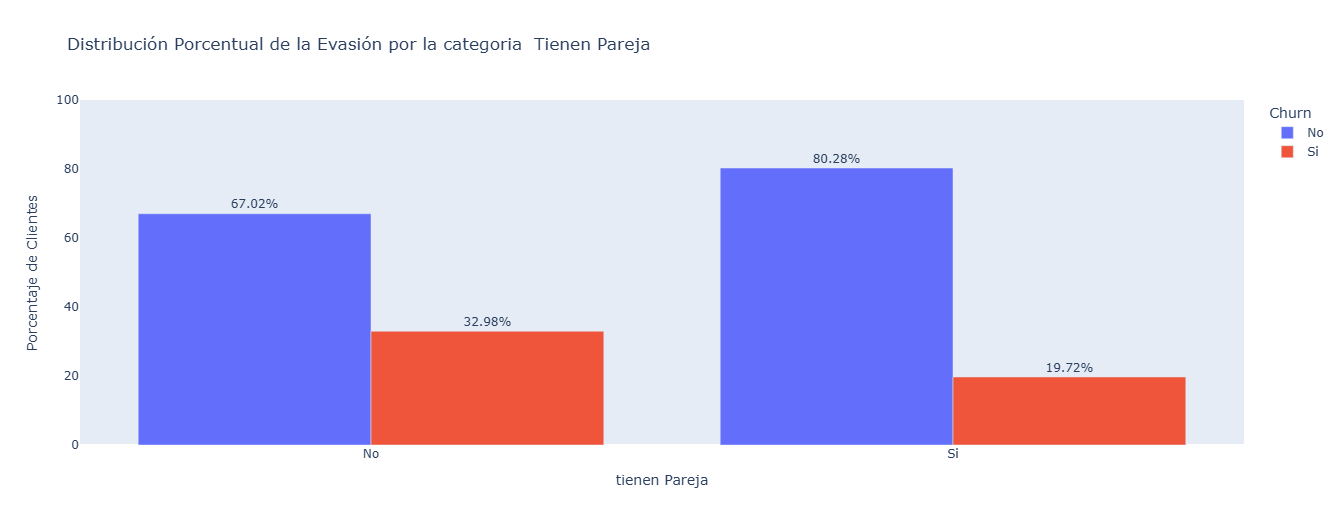




7. **Segmentación por Carga Familiar (Dependientes)**

El análisis de la base de clientes de TelecomX según la existencia de dependientes económicos (hijos, familiares a cargo, etc.) confirma una tendencia clara en la estabilidad de la cartera. Los datos extraídos muestran lo siguiente:

* Sin Dependientes: Este es el segmento predominante de la compañía con 4,933 clientes. Sin embargo, registra 1,543 bajas, lo que representa una tasa de deserción elevada del 31.28%.

* Con Dependientes: De una base de 2,099 clientes, este grupo muestra una mayor fidelidad con solo 326 cancelaciones, lo que equivale a una tasa de abandono de apenas el 15.53%.

**Conclusión del Hallazgo**
Los clientes sin dependientes no solo constituyen el volumen principal de usuarios de la empresa, sino que también presentan la mayor tendencia al abandono.

En concordancia con lo observado en el análisis de estado civil, existe una correlación directa entre los vínculos familiares y la permanencia: los clientes con menos responsabilidades familiares tienden a ser menos leales a la marca. Esta volatilidad sugiere que este segmento es más sensible a ofertas externas o cambios de estilo de vida, convirtiéndose en un grupo de atención prioritaria para las estrategias de retención.


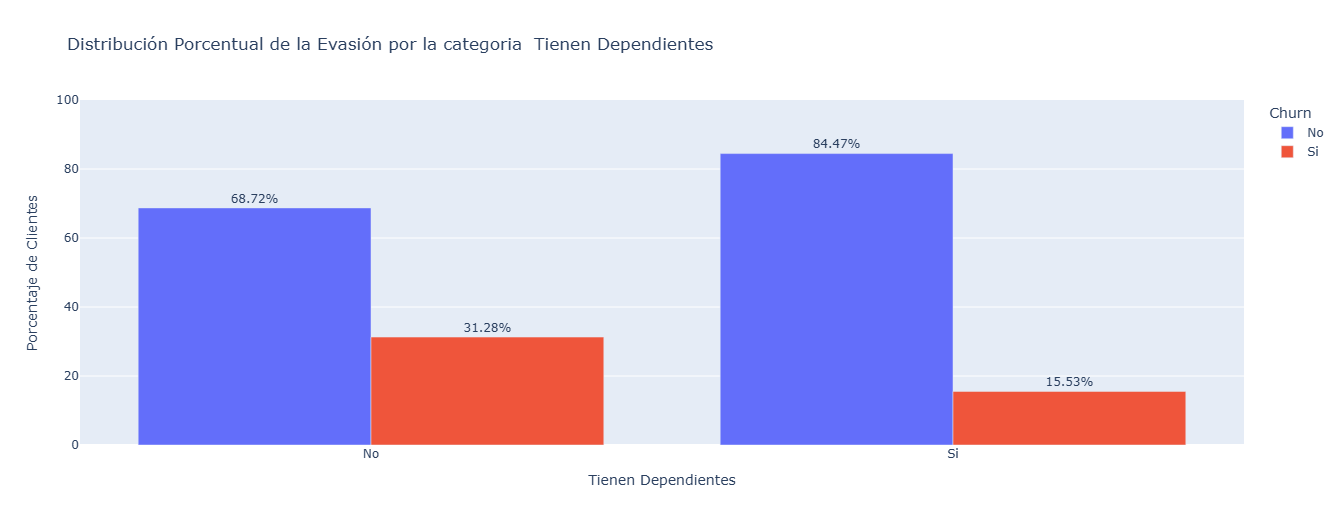


8.-**Relación Tiempo Contrato - Churn**

Se observa que el mes de inicio representa el punto crítico de mayor deserción para los clientes de TelecomX.


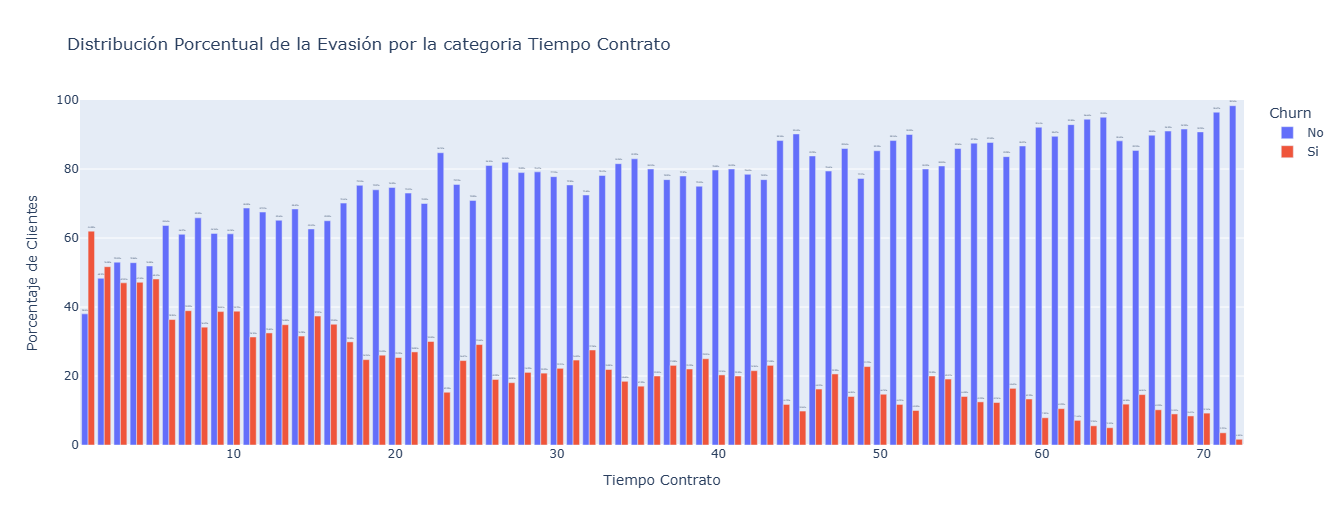


9. **Análisis de Cargos Mensuales y Totales frente al Churn**

El estudio de las variables financieras de TelecomX permite identificar patrones críticos de deserción vinculados a la percepción de costo y la permanencia del usuario. Los hallazgos principales son:

* Cargos Mensuales (Monthly Charges): Se observa una correlación directa entre el importe de la factura mensual y la tasa de abandono. Los clientes que rescinden el contrato suelen tener cargos mensuales más elevados. Esto indica que el precio corriente es un factor determinante en la pérdida de usuarios, impactando con mayor severidad en los nuevos suscriptores.

* Cargos Totales (Total Charges): Paradójicamente, los clientes que cancelan el servicio presentan un "Cargo Total" significativamente más bajo que aquellos que permanecen activos. Esto confirma que la deserción no es un proceso tardío, sino que ocurre de forma prematura en el ciclo de vida del cliente, antes de que este logre generar ingresos acumulados importantes para la compañía.

**Conclusión del Hallazgo**
Los datos revelan una combinación crítica de alto costo percibido al inicio y una baja fidelización temprana. El cliente de TelecomX percibe el servicio como "oneroso" desde la primera factura y, al no identificar un valor agregado o una experiencia que justifique dicho desembolso, opta por la cancelación rápida.

Esta brecha de valor durante los primeros meses del contrato impide que el usuario madure hacia un perfil de cliente leal, limitando drásticamente el retorno de inversión por cada nuevo usuario captado.



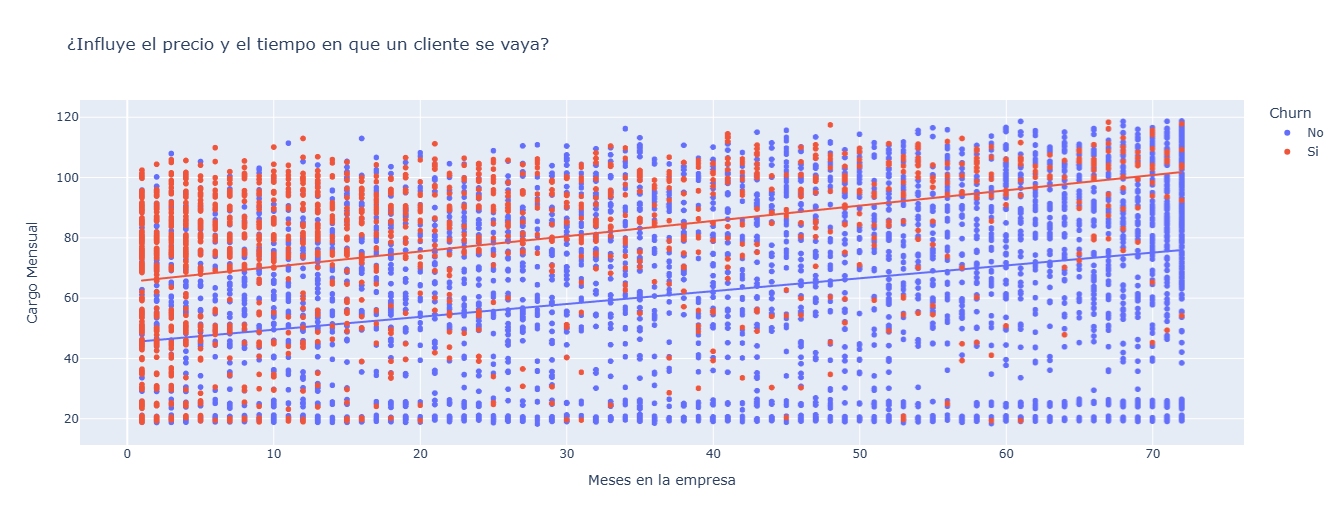

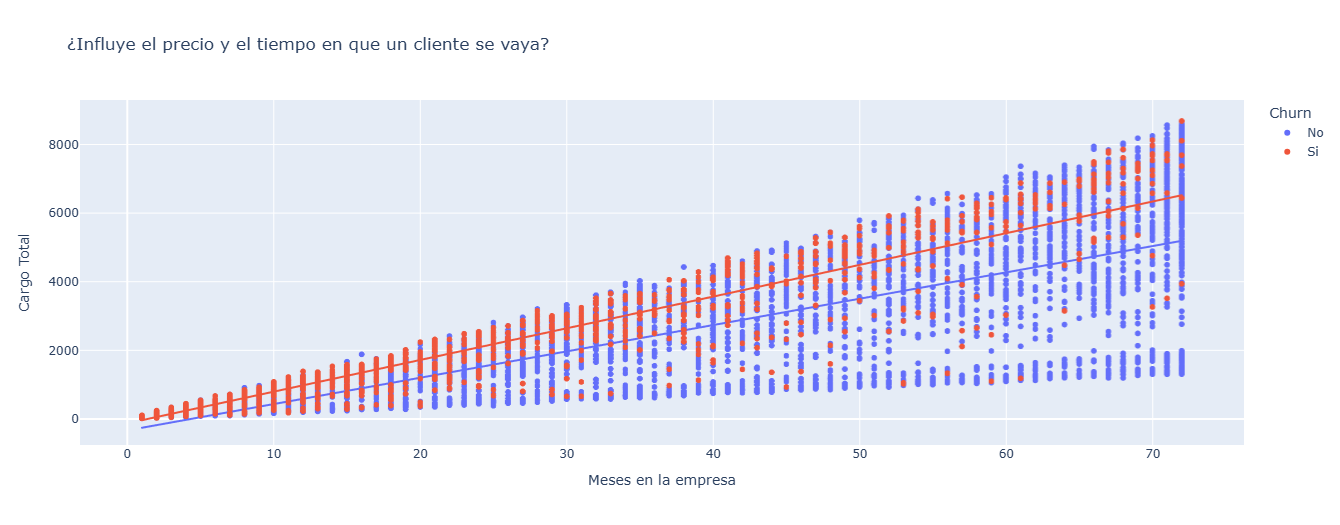



10. **Correlación entre el Costo Diario y la Tasa de Evasión (Churn)**

El análisis gráfico permite identificar una relación directa entre el valor económico de la factura diaria y la tendencia de deserción de los usuarios. Los puntos clave de esta observación son:

* Riesgo Proporcional al Costo: Se evidencia que los clientes que optan por rescindir su relación con la compañía son, predominantemente, aquellos que poseen los contratos de mayor valor monetario.

* Complejidad del Portafolio: El índice de abandono se incrementa conforme aumenta la complejidad del servicio contratado; es decir, en aquellos paquetes que integran una mayor cantidad de servicios adicionales.

**Conclusión del Hallazgo**
Los datos reflejan una alta sensibilidad al precio por parte del consumidor. Los paquetes de categoría "Premium" o con múltiples servicios agregados registran los índices de pérdida más elevados.

Este comportamiento sugiere una brecha en la percepción de valor: los clientes de alto consumo no logran identificar un beneficio o valor diferencial que justifique el elevado costo diario, lo que los motiva a cancelar el servicio con mayor rapidez que los usuarios de planes económicos.



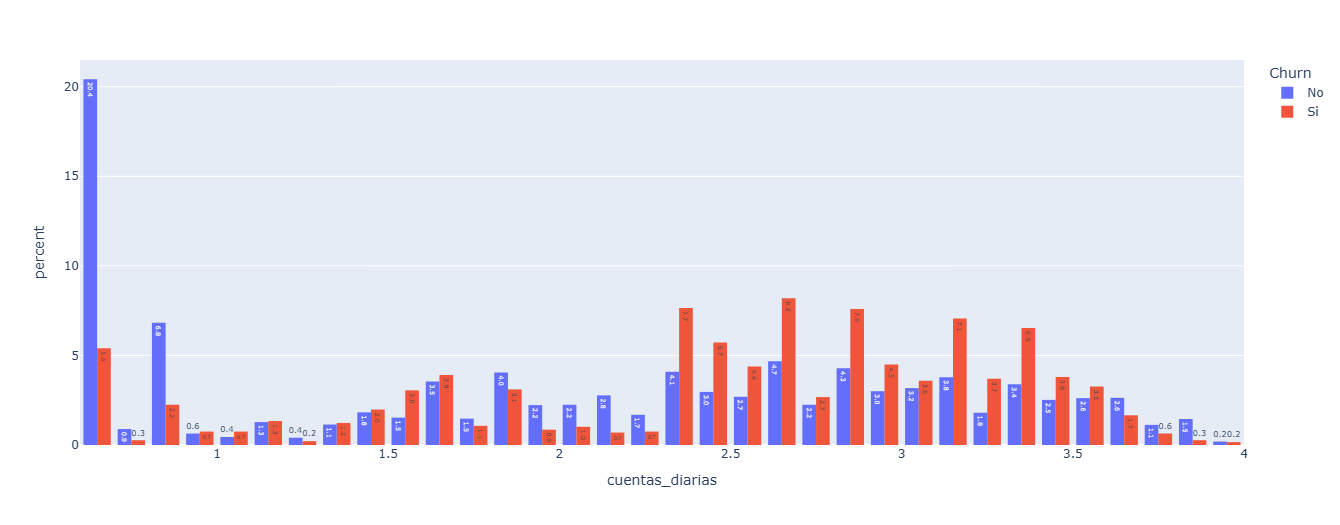

11. **Impacto de la Densidad de Servicios en la Deserción (Churn)**

El análisis del portafolio de servicios contratados por los usuarios de TelecomX revela una correlación inversa entre la cantidad de productos activos y la probabilidad de abandono. Los hallazgos principales son:

* Segmento de Baja Vinculación: Los clientes que poseen únicamente 1 o 2 servicios contratados representan el grupo con la probabilidad de deserción más alta de la compañía. Se observa que, a menor cantidad de servicios vinculados, menor es la barrera de salida para el usuario.

* Predominancia de Contratos a Corto Plazo: Este grupo de baja vinculación coincide significativamente con la modalidad de Contrato Mensual (Mes a Mes), lo que elimina cualquier compromiso de permanencia temporal.

**Conclusión del Hallazgo**
La vulnerabilidad estratégica de TelecomX se concentra en los usuarios de paquetes básicos. Al no lograr una migración hacia una mayor cantidad de servicios (cross-selling) o hacia contratos de fidelización anual, estos clientes permanecen en una categoría de alta volatilidad.

La combinación de una estructura de servicios simple y la falta de un compromiso contractual a largo plazo facilita que el cliente opte por cancelar su suscripción ante cualquier inconveniente operativo o ante ofertas competitivas del mercado.





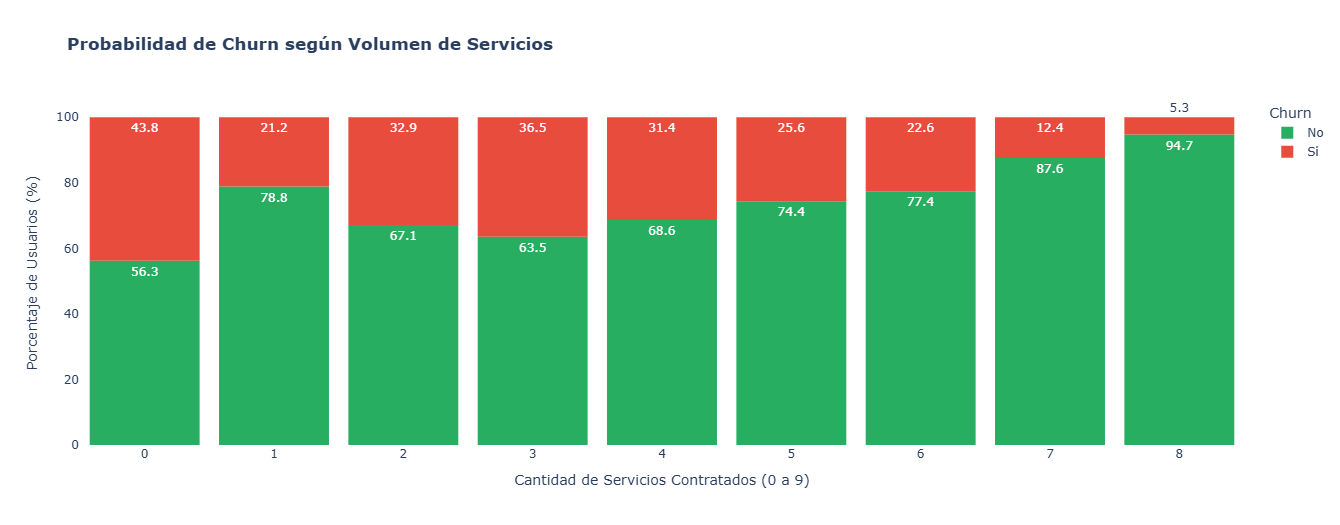

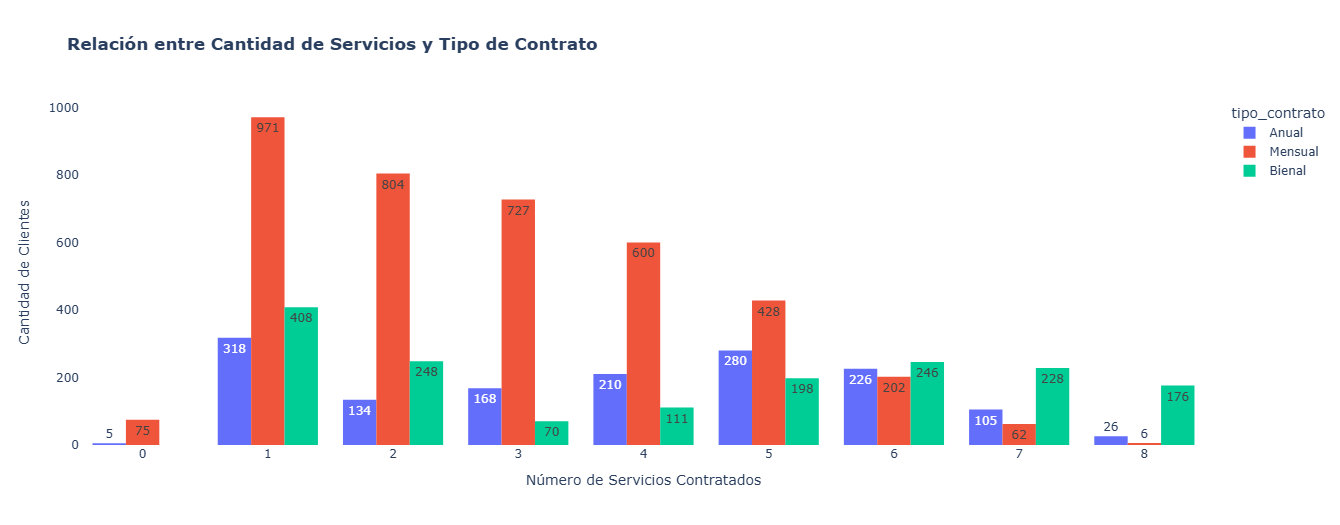

12. **Análisis de Correlaciones y Factores de Riesgo**

El análisis estadístico revela una relación directa entre el costo, el uso y la deserción de los clientes, destacando los siguientes hallazgos:

Cuentas Diarias y Churn (0.19): Esta correlación indica que el uso frecuente del servicio no garantiza la lealtad. De hecho, existe una tendencia donde los usuarios más activos son más propensos al abandono. Esto sugiere que el valor percibido no está alineado con el gasto, y que el uso intensivo aumenta la sensibilidad del cliente hacia el precio y las deficiencias del modelo contractual.

Gasto Mensual y Total de Servicios (0.19): Existe una correlación positiva idéntica que vincula el cargo mensual con la evasión. Esto demuestra que el uso intensivo no genera fidelidad, sino una mayor fiscalización del costo por parte del cliente.

**Conclusión Estratégica:**
El cliente de TelecomX percibe que a mayor actividad o cantidad de servicios, mayor es el costo sin recibir un beneficio de retención claro (como descuentos por volumen o antigüedad). Esta falta de incentivos, sumada a la ausencia de contratos de largo plazo, convierte a los usuarios más activos en el segmento con mayor riesgo de fuga.





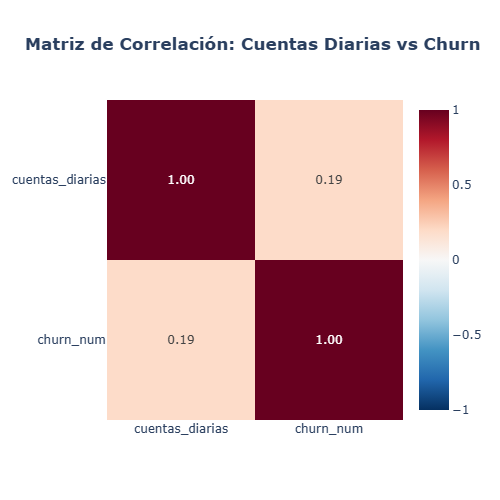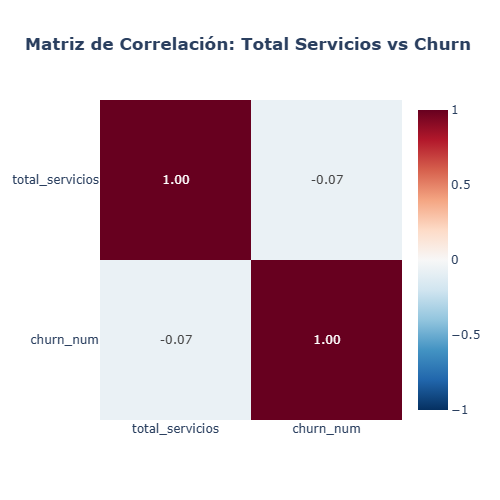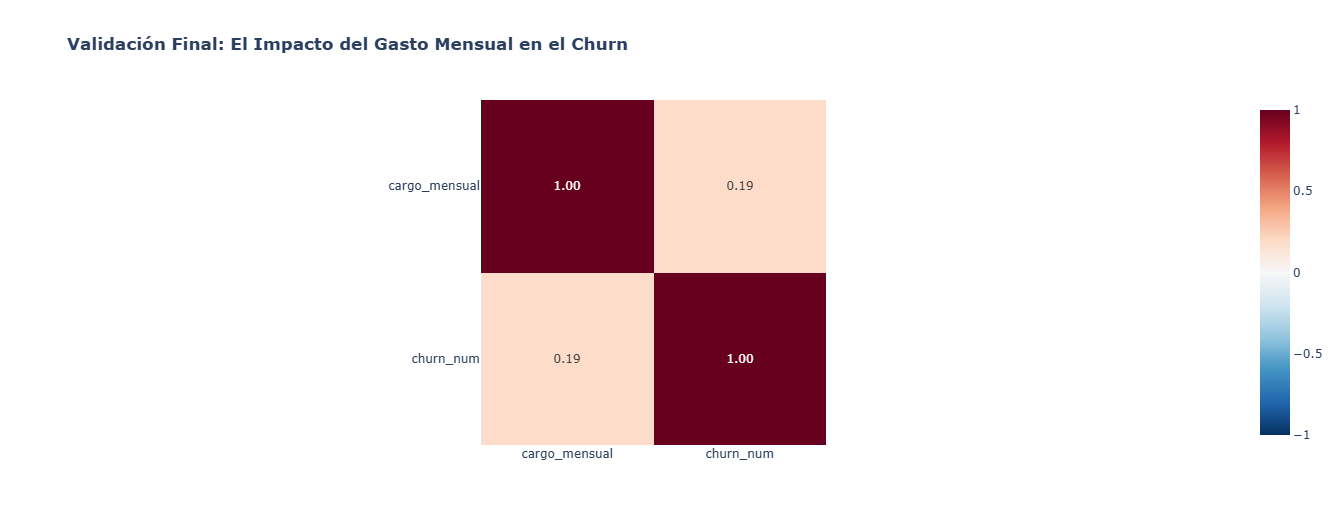


## **Conclusiones e Insights:**

Tras el análisis detallado del dataset TelecomX, se han identificado los siguientes hallazgos clave sobre el comportamiento de baja (churn) de los usuarios:

1. Fragilidad en la Retención y Modalidades de Contrato
* Volatilidad del Contrato Mensual: Los clientes con contratos mes a mes presentan la mayor tasa de rescisión. La ausencia de un compromiso a largo plazo facilita que estos usuarios abandonen la compañía ante insatisfacciones mínimas o promociones de la competencia.

* Fuga en el Primer Mes: Existe un perfil de "baja vinculación" (principalmente clientes solteros y sin dependientes) que deserta casi de inmediato, específicamente durante el primer mes de servicio.

2. Puntos Críticos en Servicios y Pagos
* Deserción en Fibra Óptica: El segmento de usuarios con el servicio de Fiber Optic es el que registra el mayor índice de bajas, lo que sugiere una posible brecha entre la expectativa del servicio y la experiencia real.

* Riesgo en el Método de Pago: Los clientes que utilizan Cheque Electrónico representan un punto crítico de abandono, siendo el método de pago con la mayor tasa de deserción asociada.

3. Análisis Demográfico y de Fidelidad
* Vulnerabilidad por Etapa de Vida: * Adultos Mayores: Aunque son un grupo menor en volumen, poseen una tasa de riesgo proporcionalmente más alta.

* No Adultos Mayores: Representan el mayor impacto en pérdida total de clientes debido a que son el segmento mayoritario de la base de datos.

* Vínculos Familiares y Lealtad: Los clientes solteros y sin dependientes no solo son el grupo predominante, sino también el menos leal. La falta de vínculos familiares parece correlacionarse con una menor fidelidad hacia la marca.

4. Percepción de Valor y Sensibilidad al Precio
* Relación Costo-Beneficio Deficiente: Los clientes perciben el servicio como costoso desde el inicio. Los paquetes "Premium" o con servicios agregados muestran la mayor pérdida, lo que indica que el usuario no percibe un valor proporcional al precio pagado.

* Falta de Incentivos por Volumen: Se observa que a mayor actividad o cantidad de servicios contratados, el cliente siente un incremento de costo sin recibir beneficios de retención claros, como descuentos por lealtad o antigüedad.

* Clientes Volátiles en Paquetes Básicos: La incapacidad de migrar a los clientes de paquetes básicos hacia contratos anuales los mantiene en una posición de "vulnerabilidad constante", listos para abandonar la empresa ante cualquier oferta externa.



## **Recomendaciones:**

Basado en los hallazgos del análisis de deserción, se proponen las siguientes líneas de acción para mitigar la fuga de clientes y fortalecer el valor de marca de TelecomX:

1. Optimización de la Experiencia Inicial (Onboarding)
* Dado que el abandono se concentra críticamente en el primer mes, es imperativo fortalecer el acompañamiento inicial:

* Programa de Bienvenida Activo: Implementar protocolos de seguimiento (llamadas o visitas técnicas de cortesía) a los 15 días de la instalación para asegurar la satisfacción técnica y resolver dudas de uso.

* Esquema de Retención Progresiva: Ofrecer descuentos escalonados durante el primer trimestre, condicionados a la permanencia, para mitigar la percepción de "alto costo inicial" y fomentar el hábito de pago.

2. Digitalización y Estabilidad Contractual
* Para reducir la volatilidad asociada a los Contratos Mensuales y el uso de Cheque Electrónico:

* Incentivos por Automatización de Pago: Promover la migración a Débito Automático (Tarjeta de Crédito/Débito) mediante descuentos exclusivos (ej. 5% - 10%). Esto reduce la fricción transaccional y mejora la tasa de cobranza.

* Conversión a Contratos Anuales: Diseñar ofertas de "Upgrade" que permitan acceder a tarifas preferenciales a cambio de una vinculación de 12 meses, creando una barrera de salida técnica y legal.

3. Revalorización del Servicio de Fibra Óptica
* Considerando que la Fibra Óptica presenta la mayor tasa de deserción, se sugiere:

* Auditoría de Calidad y Valor: Ejecutar un diagnóstico para determinar si las bajas responden a fallas técnicas o sensibilidad al precio.

* Empaquetamiento de Valor (Bundling): Integrar servicios de valor agregado (como plataformas de streaming) en los planes de fibra para que el cliente perciba un beneficio tangible que justifique el costo premium.

4. Fidelización de Segmentos Volátiles (Solteros y sin Dependientes)
* Al ser el grupo más numeroso y propenso al abandono, requiere estrategias de "anclaje":

* Programa de Lealtad por Antigüedad: Implementar un sistema de puntos o beneficios crecientes cada 6 meses. La percepción de "pérdida de beneficios acumulados" actúa como un desincentivo para la cancelación.

* Estrategia de Venta Cruzada (Cross-selling): Fomentar la contratación de múltiples servicios. La evidencia sugiere que a mayor número de productos vinculados, la complejidad de migrar a la competencia aumenta, elevando la lealtad del cliente.

5. Atención Especializada al Segmento Silver (Adultos Mayores)
* A pesar de ser un grupo menor en volumen, su tasa de riesgo del 41% exige una intervención focalizada:

* Canal de Soporte Prioritario: Establecer una línea de atención humana y personalizada. La simplificación en la explicación de facturas y el soporte técnico asistido pueden reducir drásticamente las bajas por frustración tecnológica.